# Project Info .... names , abstract , ... #TODO

# Part1 - BERT Fine-Tuning

In [1]:
# In the name of God
# Deep Learning Project
# Dr. Fatemizadeh

# Import necessary libraries

!pip -q install transformers



#import os

import torch
import numpy as np
from torch.utils.data import DataLoader, Dataset

import torch.nn as nn
from transformers import AdamW
from transformers import get_linear_schedule_with_warmup # for scheduler!



import matplotlib.pyplot as plt

import torch
from transformers import AutoTokenizer, AutoModel

from transformers import BertTokenizer, BertForSequenceClassification


import random
import json
import time
student_names = "\nNavid Farmahini Farahani\nMatin Armanmehr\nSajjad Hashembeiki"

print("Names of students:", student_names)


Names of students: 
Navid Farmahini Farahani
Matin Armanmehr
Sajjad Hashembeiki


In [2]:

seed_val = 42
random.seed(seed_val)
np.random.seed(seed_val)
torch.manual_seed(seed_val)
if torch.cuda.is_available():
  torch.cuda.manual_seed_all(seed_val)

In [3]:
# Load JSON files
# !gdown 1oh9c-d0fo3NtETNySmCNLUc6H1j4dSWE
# !gdown 1k5LMwmYF7PF-BzYQNE2ULBae79nbM268

!gdown 1LFeGWL49PX5JujrQ2zMbSgxuAFA-Xmbf
!gdown 1SZNvp_hYVczqe0rM1AZKu9tXTE7qHN1j


Downloading...
From: https://drive.google.com/uc?id=1oh9c-d0fo3NtETNySmCNLUc6H1j4dSWE
To: /content/subtaskB_dev.jsonl
100% 4.93M/4.93M [00:00<00:00, 113MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1k5LMwmYF7PF-BzYQNE2ULBae79nbM268
From (redirected): https://drive.google.com/uc?id=1k5LMwmYF7PF-BzYQNE2ULBae79nbM268&confirm=t&uuid=ec922653-69dd-4d9f-8f1d-355584b82020
To: /content/subtaskB_train.jsonl
100% 155M/155M [00:00<00:00, 241MB/s]


In [4]:
# We use this function for changing the device
def to_device(data, device):
    # for every batch, we pass the data to the current device.
    if isinstance(data, (list,tuple)):
        return [to_device(x, device) for x in data]
    return data.to(device, non_blocking=True)


# We use this class for passing the data and model to the device
class DeviceDataLoader():
    def __init__(self, dl, device):
        self.dl=dl
        self.device=device

    def __iter__(self):
        #For every batch, we pass it to the current device.
        for b in self.dl:
            yield to_device(b, self.device)

    def __len__(self):
        return len(self.dl)

# Selecting the current device
if torch.cuda.is_available():
      device=torch.device('cuda')
else:
      device=torch.device('cpu')

print("The device is:",device)


The device is: cuda


In [5]:
# Setting the tokenized and model
bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')


/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:88: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

In [6]:
## Load dataset and make list of texts and their labels

all_texts=[]
all_labels=[]
all_names=[]
with open('subtaskB_train.jsonl','r') as f:
  for line in f:
          data = json.loads(line)
          all_texts.append(data['text'])
          all_labels.append(data['label'])



all_texts_test=[]
all_labels_test=[]
all_names_test=[]

with open('subtaskB_dev.jsonl','r') as f:
  for line in f:
          data = json.loads(line)
          all_texts_test.append(data['text'])
          all_labels_test.append(data['label'])



In [7]:
class BERT_Dataset(Dataset):
  def __init__(self, text, labels,label_masks, max_len):
    self.text = text
    self.labels = np.array(labels)# np.array!!
    self.label_masks=label_masks
    self.max_len = max_len


  def __getitem__(self,index):

    tokenized_text = bert_tokenizer.encode_plus(self.text[index],
                                          max_length = self.max_len,
                                          return_tensors="pt",
                                          truncation = True,
                                          add_special_tokens=True,
                                          padding="max_length",
                                          return_attention_mask=True
                                        )

    return tokenized_text.input_ids.squeeze(), tokenized_text.attention_mask.squeeze(), tokenized_text.token_type_ids.squeeze(),self.labels[index],self.label_masks[index]


  def __len__(self):
    return len(self.text)




In [12]:
# We shuffle the dataset in order to pick some data from it for Labeled Data and others are Non-Labeled Data

#### Shuffling the dataset


the_list=list(range(0,len(all_texts)))
selector=the_list[0:int(len(all_texts))]
np.random.shuffle(selector)

all_texts_shuffled=[]
all_labels_shuffled=[]

for i in range(len(selector)):
  all_texts_shuffled.append(all_texts[selector[i]])
  all_labels_shuffled.append(all_labels[selector[i]])


print("We have",len(all_texts),"data for train and test")



learning_rate = 2e-5
epochs = 3
percentage=[0.01,0.05,0.1,0.5]
batch_size = 128
max_len=64

print('max_length for tokenizing is :',max_len)# Unfortunately we cannot consider the maximum length of the data for tokenizing(e.g. 7000)
# so, we need to consider a lower length
# If we consider max_len=512, the results will be better but it will be very very time consuming in part 3 !!!


We have 71027 data for train and test
max_length for tokenizing is : 64


##############################



This model considers 1.0 % of the data for supervised learning, so all other data are redundant in part 1
We have  710 Data for train
We have  3000 Data for test


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.







Training has been started!!
################################ 






Step: 1   From 5   Loss: 1.821419596672058
Step: 2   From 5   Loss: 1.8407807350158691
Step: 3   From 5   Loss: 1.7646185159683228
Step: 4   From 5   Loss: 1.8041203022003174
Step: 5   From 5   Loss: 1.795501708984375
Train Accuracy For 20 Steps:  20.3125 %
Step: 6   From 5   Loss: 1.8009326457977295
Epoch 1/3
Average Train Loss: tensor(1.8046) Average Train Accuracy: tensor(20.3125)
Step: 1   From 5   Loss: 1.795884370803833
Step: 2   From 5   Loss: 1.727501392364502
Step: 3   From 5   Loss: 1.785327434539795
Step: 4   From 5   Loss: 1.7587695121765137
Step: 5   From 5   Loss: 1.7411315441131592
Train Accuracy For 20 Steps:  22.65625 %
Step: 6   From 5   Loss: 1.713255763053894
Epoch 2/3
Average Train Loss: tensor(1.7536) Average Train Accuracy: tensor(22.6562)
Step: 1   From 5   Loss: 1.73371422290802
Step: 2   From 5   Loss: 1.717473030090332
Step: 3   From 5   Loss: 1.6841131448745728
Step: 4   From 5   Loss: 

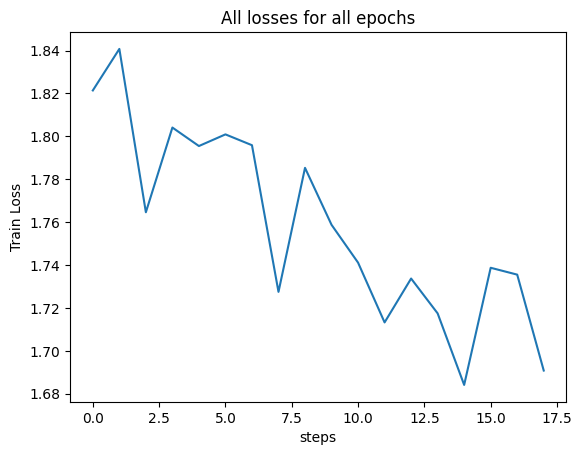

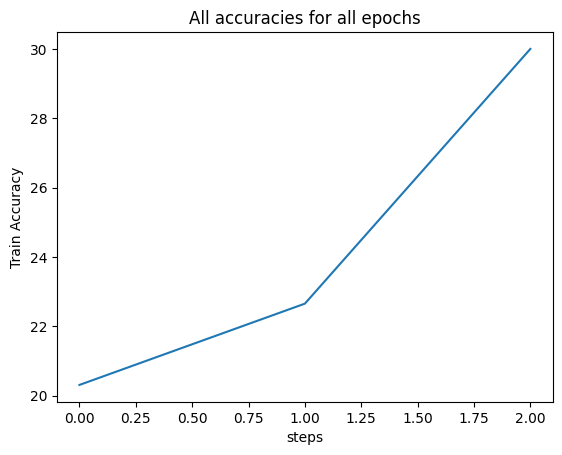

710
Step: 5 From 23
Tes loss: 1.7704782485961914 Preds: tensor([5, 1, 5, 1, 5, 5, 5, 1, 5, 4, 4, 1, 5, 1, 5, 1, 5, 5, 1, 1, 5, 5, 5, 1,
        1, 1, 5, 5, 1, 0, 4, 1, 4, 4, 5, 5, 5, 1, 1, 1, 4, 4, 1, 5, 5, 5, 4, 5,
        5, 1, 1, 1, 1, 5, 5, 4, 1, 4, 1, 1, 5, 1, 1, 1, 5, 1, 5, 5, 5, 1, 4, 5,
        1, 5, 1, 4, 5, 1, 5, 1, 1, 1, 5, 5, 1, 5, 1, 1, 5, 1, 5, 5, 5, 1, 1, 5,
        1, 5, 5, 1, 4, 1, 5, 5, 4, 5, 5, 1, 5, 5, 5, 5, 1, 4, 5, 1, 5, 5, 5, 1,
        1, 4, 5, 5, 4, 4, 1, 4], device='cuda:0') Labels: tensor([4, 4, 2, 2, 2, 4, 5, 2, 0, 0, 0, 5, 4, 5, 3, 5, 4, 0, 5, 5, 5, 1, 3, 0,
        2, 2, 5, 3, 0, 1, 1, 4, 3, 3, 5, 0, 4, 1, 4, 0, 5, 5, 4, 1, 4, 4, 4, 1,
        4, 1, 3, 1, 1, 1, 4, 4, 3, 2, 3, 3, 1, 5, 2, 5, 2, 5, 3, 0, 2, 0, 2, 1,
        1, 1, 0, 0, 4, 1, 0, 1, 2, 1, 0, 5, 5, 2, 2, 1, 1, 4, 3, 3, 3, 1, 3, 4,
        3, 5, 5, 4, 3, 5, 3, 1, 0, 2, 2, 5, 3, 2, 5, 4, 4, 4, 5, 2, 2, 2, 0, 2,
        5, 1, 2, 5, 5, 5, 1, 1], device='cuda:0')
Test Accuracy For 20 Steps:  18.9062

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.







Training has been started!!
################################ 






Step: 1   From 27   Loss: 1.8498907089233398
Step: 2   From 27   Loss: 1.8972896337509155
Step: 3   From 27   Loss: 1.8211573362350464
Step: 4   From 27   Loss: 1.8167601823806763
Step: 5   From 27   Loss: 1.8282108306884766
Train Accuracy For 20 Steps:  15.46875 %
Step: 6   From 27   Loss: 1.7947070598602295
Step: 7   From 27   Loss: 1.8351746797561646
Step: 8   From 27   Loss: 1.7818357944488525
Step: 9   From 27   Loss: 1.7812728881835938
Step: 10   From 27   Loss: 1.758766531944275
Train Accuracy For 20 Steps:  22.1875 %
Step: 11   From 27   Loss: 1.7716273069381714
Step: 12   From 27   Loss: 1.7673709392547607
Step: 13   From 27   Loss: 1.787980079650879
Step: 14   From 27   Loss: 1.7511036396026611
Step: 15   From 27   Loss: 1.7430644035339355
Train Accuracy For 20 Steps:  21.875 %
Step: 16   From 27   Loss: 1.7577301263809204
Step: 17   From 27   Loss: 1.7413870096206665
Step: 18   From 27   Loss: 1.7012300

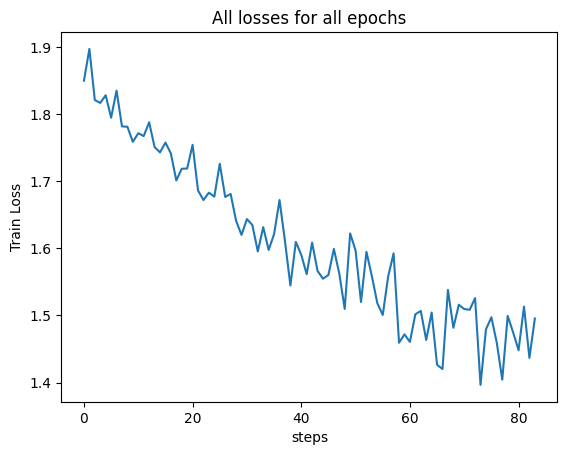

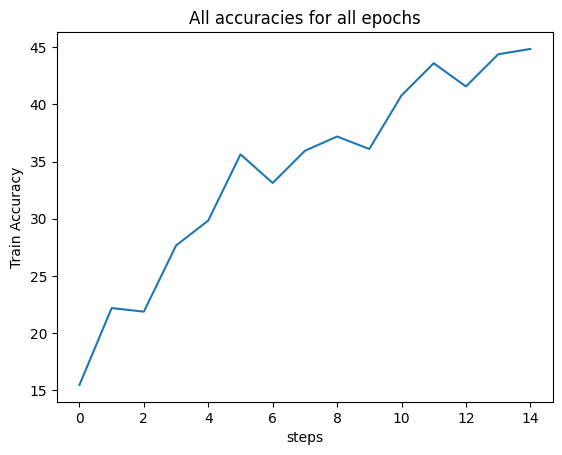

3551
Step: 5 From 23
Tes loss: 1.7474334239959717 Preds: tensor([4, 1, 1, 1, 4, 3, 1, 1, 3, 1, 4, 3, 1, 1, 1, 1, 3, 3, 4, 4, 1, 4, 1, 3,
        1, 3, 1, 2, 1, 3, 3, 3, 3, 3, 3, 1, 3, 4, 1, 3, 4, 3, 3, 4, 3, 1, 3, 3,
        1, 3, 1, 3, 4, 4, 1, 3, 3, 3, 3, 3, 3, 4, 1, 4, 4, 4, 3, 1, 3, 3, 1, 1,
        0, 2, 3, 4, 3, 4, 2, 3, 1, 1, 4, 1, 1, 4, 3, 1, 3, 1, 3, 3, 4, 1, 3, 3,
        1, 3, 1, 2, 3, 4, 5, 1, 1, 3, 1, 3, 1, 4, 3, 3, 0, 1, 1, 4, 1, 3, 1, 4,
        4, 1, 3, 3, 4, 4, 1, 3], device='cuda:0') Labels: tensor([1, 4, 0, 3, 2, 1, 5, 3, 4, 4, 0, 1, 1, 4, 2, 3, 3, 2, 4, 5, 3, 0, 4, 2,
        3, 0, 2, 1, 0, 2, 2, 2, 1, 4, 1, 5, 3, 4, 1, 3, 0, 3, 0, 5, 1, 5, 1, 3,
        0, 1, 3, 5, 5, 4, 0, 5, 5, 1, 2, 1, 1, 4, 2, 0, 4, 5, 5, 2, 3, 2, 3, 5,
        0, 2, 0, 4, 3, 0, 0, 0, 5, 5, 5, 1, 3, 4, 3, 2, 3, 1, 0, 3, 4, 3, 1, 3,
        2, 2, 2, 5, 4, 1, 1, 2, 1, 5, 2, 1, 4, 1, 3, 0, 0, 0, 1, 0, 3, 3, 2, 0,
        4, 3, 5, 1, 4, 4, 1, 5], device='cuda:0')
Test Accuracy For 20 Steps:  25.625

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.







Training has been started!!
################################ 






Step: 1   From 55   Loss: 1.8235512971878052
Step: 2   From 55   Loss: 1.8456273078918457
Step: 3   From 55   Loss: 1.8147938251495361
Step: 4   From 55   Loss: 1.7876263856887817
Step: 5   From 55   Loss: 1.7866122722625732
Train Accuracy For 20 Steps:  15.3125 %
Step: 6   From 55   Loss: 1.7767207622528076
Step: 7   From 55   Loss: 1.78594172000885
Step: 8   From 55   Loss: 1.8048715591430664
Step: 9   From 55   Loss: 1.773995280265808
Step: 10   From 55   Loss: 1.77703058719635
Train Accuracy For 20 Steps:  19.84375 %
Step: 11   From 55   Loss: 1.784731388092041
Step: 12   From 55   Loss: 1.7954729795455933
Step: 13   From 55   Loss: 1.7766739130020142
Step: 14   From 55   Loss: 1.7704228162765503
Step: 15   From 55   Loss: 1.770632266998291
Train Accuracy For 20 Steps:  19.375 %
Step: 16   From 55   Loss: 1.7705631256103516
Step: 17   From 55   Loss: 1.7337117195129395
Step: 18   From 55   Loss: 1.754193663597

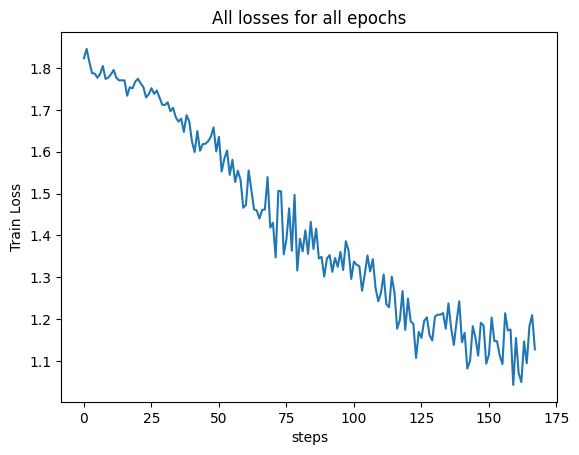

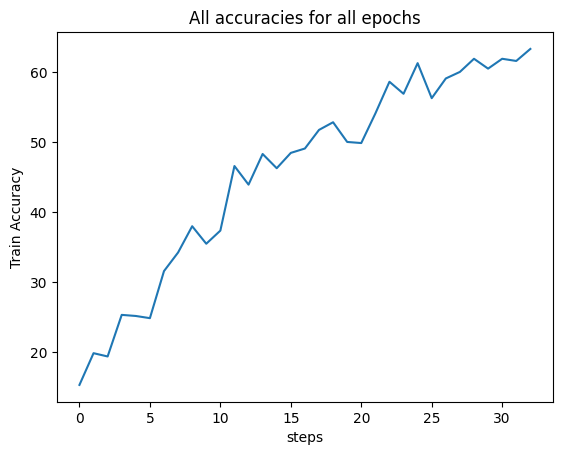

7102
Step: 5 From 23
Tes loss: 1.6370415687561035 Preds: tensor([1, 4, 4, 1, 2, 3, 3, 1, 3, 3, 3, 1, 4, 3, 3, 4, 1, 1, 1, 1, 3, 3, 1, 2,
        5, 3, 0, 3, 3, 3, 5, 1, 0, 4, 3, 5, 4, 1, 1, 3, 4, 3, 4, 0, 1, 3, 3, 4,
        3, 1, 1, 4, 3, 4, 1, 2, 3, 3, 1, 5, 0, 4, 1, 4, 1, 4, 4, 1, 3, 3, 1, 5,
        3, 3, 5, 1, 5, 4, 4, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 4, 3, 4, 1, 5, 2,
        3, 0, 4, 1, 1, 4, 1, 1, 1, 1, 0, 0, 1, 3, 4, 1, 5, 4, 1, 3, 1, 5, 3, 3,
        1, 1, 1, 1, 1, 3, 4, 3], device='cuda:0') Labels: tensor([1, 5, 4, 5, 1, 0, 3, 1, 5, 3, 1, 3, 4, 2, 2, 4, 2, 3, 5, 2, 0, 2, 2, 1,
        4, 1, 0, 2, 1, 1, 0, 3, 0, 4, 1, 5, 4, 1, 2, 0, 4, 5, 4, 0, 2, 5, 4, 4,
        5, 3, 1, 4, 5, 4, 3, 1, 5, 0, 2, 1, 0, 4, 5, 4, 3, 4, 4, 2, 2, 5, 1, 2,
        5, 2, 3, 3, 0, 2, 0, 5, 3, 4, 0, 5, 3, 5, 5, 1, 2, 3, 4, 5, 4, 3, 0, 2,
        2, 0, 4, 2, 3, 5, 2, 5, 5, 3, 5, 0, 2, 3, 0, 1, 1, 0, 2, 5, 2, 5, 0, 1,
        1, 3, 5, 4, 1, 0, 4, 2], device='cuda:0')
Test Accuracy For 20 Steps:  33.75 

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.







Training has been started!!
################################ 






Step: 1   From 277   Loss: 1.761519193649292
Step: 2   From 277   Loss: 1.8126397132873535
Step: 3   From 277   Loss: 1.8509732484817505
Step: 4   From 277   Loss: 1.780914068222046
Step: 5   From 277   Loss: 1.8113155364990234
Train Accuracy For 20 Steps:  21.5625 %
Step: 6   From 277   Loss: 1.8174326419830322
Step: 7   From 277   Loss: 1.7751013040542603
Step: 8   From 277   Loss: 1.7896796464920044
Step: 9   From 277   Loss: 1.7999911308288574
Step: 10   From 277   Loss: 1.7662954330444336
Train Accuracy For 20 Steps:  21.25 %
Step: 11   From 277   Loss: 1.7740256786346436
Step: 12   From 277   Loss: 1.756904125213623
Step: 13   From 277   Loss: 1.765303373336792
Step: 14   From 277   Loss: 1.7625322341918945
Step: 15   From 277   Loss: 1.7685675621032715
Train Accuracy For 20 Steps:  22.5 %
Step: 16   From 277   Loss: 1.7642083168029785
Step: 17   From 277   Loss: 1.7981549501419067
Step: 18   From 277   Loss

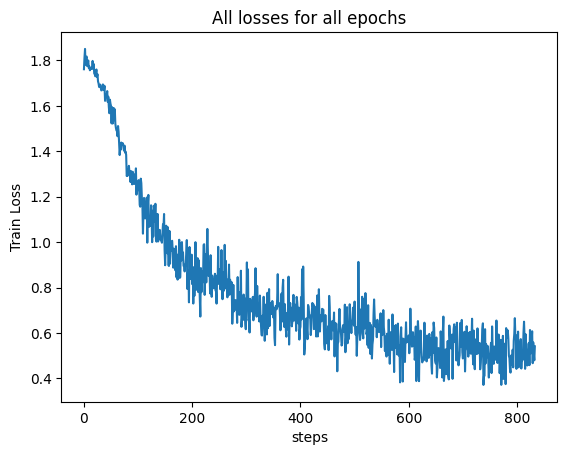

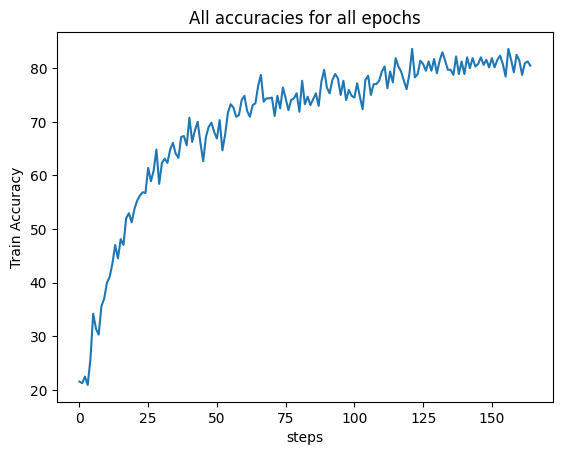

35513
Step: 5 From 23
Tes loss: 1.4012582302093506 Preds: tensor([4, 1, 4, 3, 3, 4, 3, 1, 3, 5, 3, 3, 4, 4, 3, 2, 4, 4, 0, 3, 1, 4, 2, 0,
        1, 5, 3, 5, 4, 5, 5, 5, 4, 0, 3, 3, 3, 2, 5, 1, 5, 3, 3, 1, 5, 3, 4, 5,
        3, 4, 3, 4, 3, 4, 5, 5, 1, 1, 5, 5, 3, 5, 3, 0, 3, 5, 1, 3, 5, 3, 5, 2,
        3, 5, 3, 1, 0, 3, 3, 3, 3, 3, 0, 4, 4, 4, 3, 1, 3, 4, 2, 4, 3, 3, 0, 5,
        3, 1, 2, 4, 3, 2, 3, 1, 3, 2, 3, 4, 5, 3, 3, 1, 5, 4, 3, 4, 5, 0, 2, 3,
        0, 3, 4, 1, 5, 2, 2, 3], device='cuda:0') Labels: tensor([4, 1, 4, 2, 2, 4, 5, 1, 2, 5, 3, 3, 4, 4, 3, 5, 4, 4, 5, 2, 1, 4, 1, 5,
        3, 2, 3, 5, 4, 2, 5, 5, 4, 0, 2, 5, 3, 0, 5, 1, 0, 3, 1, 1, 2, 3, 4, 5,
        3, 4, 0, 0, 5, 4, 5, 1, 2, 1, 5, 5, 0, 0, 2, 5, 2, 2, 2, 2, 5, 4, 5, 1,
        5, 5, 2, 1, 0, 2, 2, 1, 3, 2, 0, 4, 4, 4, 1, 2, 1, 4, 3, 4, 5, 3, 0, 0,
        5, 3, 2, 4, 3, 5, 2, 1, 1, 2, 2, 5, 2, 3, 1, 5, 5, 4, 3, 4, 3, 5, 1, 3,
        0, 0, 4, 4, 0, 1, 1, 3], device='cuda:0')
Test Accuracy For 20 Steps:  52.5 

In [ ]:
########## Training the model of all the percentages

average_accs_for_all_percentages=[]

test_dataset = BERT_Dataset(text = all_texts_test,
                                labels = all_labels_test,
                                label_masks=torch.ones(len(all_labels_test)).to(device),
                                max_len = max_len)

test_loader = DataLoader(test_dataset, batch_size = batch_size, shuffle = True)
test_loader = DeviceDataLoader(test_loader, device)

loss_fn = torch.nn.CrossEntropyLoss()


for percentage_index in range(len(percentage)):


    print("##############################\n\n\n")

    print("This model considers",100*percentage[percentage_index],"% of the data for supervised learning, so all other data are redundant in part 1")
    # We Define a mask for implementing semi-supervised, we won't use this mask in part 1.

    all_labels_masks=torch.ones(len(all_labels),dtype=bool).to(device)
    for i in range(int(percentage[percentage_index]*len(all_texts_shuffled)),len(all_texts_shuffled)):
      all_labels_masks[i]=False








    train_dataset_with_label = BERT_Dataset(text = all_texts_shuffled[:int(percentage[percentage_index]*len(all_texts_shuffled))],
                                labels = all_labels_shuffled[:int(percentage[percentage_index]*len(all_texts_shuffled))],
                                label_masks=all_labels_masks[:int(percentage[percentage_index]*len(all_texts_shuffled))],
                                max_len = max_len)


    # used_train_dataset_with_label,non_used_train_dataset_with_label=torch.utils.data.random_split(train_dataset_with_label,[int(0.1*len(train_dataset_with_label)), len(train_dataset_with_label)-int(0.1*len(train_dataset_with_label))])


    # train_loader_with_label = DataLoader(used_train_dataset_with_label, batch_size = batch_size, shuffle = False)


    train_loader_with_label = DataLoader(train_dataset_with_label, batch_size = batch_size, shuffle = True)




    train_loader_with_label = DeviceDataLoader(train_loader_with_label, device)






    print("We have ",len(train_dataset_with_label),"Data for train")

    #print("We have ",len(used_train_dataset_with_label),"Data for train")


    print("We have ",len(test_dataset),"Data for test")







    total_steps = len(train_loader_with_label) * epochs






    # We have 6 classes for classification, so we have:

    num_class = 6

    bert_model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=num_class)

    bert_model = to_device(bert_model, device)

    optimizer = torch.optim.AdamW(bert_model.parameters(), lr=learning_rate)

    scheduler = get_linear_schedule_with_warmup(
      optimizer,
      num_warmup_steps=0,
      num_training_steps=total_steps
    )

    total_loss_for_all_epochs=[]
    total_acc_for_all_epochs=[]

    print("\n\n\n\n\nTraining has been started!!")
    print("################################ \n\n\n\n\n\n")


    tic=time.time()
    for epoch in range(epochs):
        bert_model.train()
        total_loss=[]
        total_acc=[]
        total_samples= 0
        total_correct= 0
        i=0
        for batch in train_loader_with_label:
            i=i+1
            input_ids, attention_mask, token_type_ids, label,_ = batch

            optimizer.zero_grad()


            outputs = bert_model(input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids, labels=label)


            #loss=loss_fn(outputs.logits,label)
            loss = outputs.loss


            total_loss.append(loss.item())
            total_loss_for_all_epochs.append(loss.item())
            loss.backward()
            optimizer.step()
            scheduler.step()
            print("Step:",i,"  From",len(train_dataset_with_label)//batch_size, "  Loss:",loss.item())
            _, preds = torch.max(outputs[1], dim = 1)
            total_samples += label.size(0)
            total_correct += (preds == label).sum().item()


            if i%5 == 0:
              acc_train=100*total_correct/total_samples

              print("Train Accuracy For 20 Steps: ",acc_train,"%")
              total_correct=0
              total_samples=0
              total_acc.append(acc_train)
              total_acc_for_all_epochs.append(acc_train)

        print(f"Epoch {epoch + 1}/{epochs}")
        print("Average Train Loss:", torch.mean(torch.tensor(total_loss)),"Average Train Accuracy:", torch.mean(torch.tensor(total_acc)))


    toc=time.time()

    print("Elapsed time is",round(toc-tic,5),"seconds")

    plt.plot(total_loss_for_all_epochs)
    plt.title("All losses for all epochs")
    plt.ylabel("Train Loss")
    plt.xlabel("steps")

    plt.show()

    plt.plot(total_acc_for_all_epochs)
    plt.title("All accuracies for all epochs")
    plt.ylabel("Train Accuracy")
    plt.xlabel("steps")

    plt.show()

    print(len(train_dataset_with_label))


    bert_model.eval()
    total_loss = 0.0
    i = 0
    total_loss=[]
    total_acc=[]
    total_samples= 0
    total_correct= 0
    for batch in test_loader:
        i += 1
        input_ids, attention_mask, token_type_ids, label, label_mask = batch

        outputs = bert_model(input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids, labels=label)
        loss = outputs.loss
        total_loss.append(loss.item())


        _, preds = torch.max(outputs[1], dim = 1)
        total_samples += label.size(0)
        total_correct += (preds == label).sum().item()

        if i%5 == 0:
          acc=100*total_correct/total_samples
          total_acc.append(acc)
          print("Step:",i,"From",len(test_dataset)//batch_size)
          print('Tes loss:',loss.item(),'Preds:',preds,"Labels:",label)
          print("Test Accuracy For 20 Steps: ",acc,"%")
          total_correct=0
          total_samples=0


    average_loss =torch.mean(torch.tensor(total_loss))
    average_acc =torch.mean(torch.tensor(total_acc))
    print("Average Test Loss:",average_loss,"\nAverage Test Accuracy:",average_acc)

    average_accs_for_all_percentages.append(average_acc)



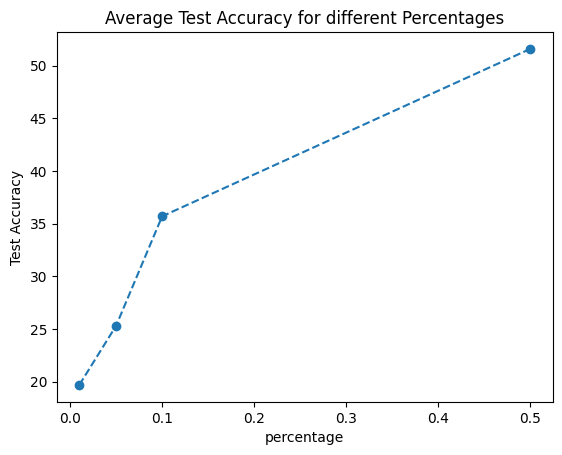

Data saved to data.xlsx


In [ ]:
import pandas as pd


plt.plot(percentage,average_accs_for_all_percentages, marker='o', linestyle='--')
plt.title("Average Test Accuracy for different Percentages")
plt.ylabel("Test Accuracy")
plt.xlabel("percentage")


plt.show()

df = pd.DataFrame({'percent': percentage, 'acc': average_accs_for_all_percentages})

# Save the DataFrame to an Excel file
df.to_excel('data.xlsx', index=False)

print("Data saved to data.xlsx")

# Part2 - Adapter (Bonus) - Method 1

In [13]:

from transformers import BertModel

class BertWithAdapters(BertForSequenceClassification):
    def __init__(self, config, m=512):
        super().__init__(config)

        # Custom layernorm module to be used in BertLayer
        class AdapterLayerNorm(nn.Module):
            def __init__(self, norm_layer):
                super().__init__()
                self.adapter = AdapterForTransformer(norm_layer.normalized_shape[0], m)

            def forward(self, x):
                return self.adapter(x)

        # Recursively traverse all layers and replace layernorm with adapter layernorm
        def replace_layernorm_with_adapters(model):
            for name, child in model.named_children():
                if isinstance(child, nn.LayerNorm):
                    setattr(model, name, AdapterLayerNorm(child))
                else:
                    replace_layernorm_with_adapters(child)

        # Replace layernorms for the BertModel part of the sequence classifier
        replace_layernorm_with_adapters(self.bert)

        # Freeze all parameters in the model
        self.freeze_parameters()

    def freeze_parameters(self):
        # Freeze all parameters first
        for param in self.parameters():
            param.requires_grad = False

        # Unfreeze parameters in AdapterForTransformer
        for name, sub_module in self.named_modules():
            if isinstance(sub_module, AdapterForTransformer):
                for param in sub_module.parameters():
                    param.requires_grad = True

class AdapterForTransformer(nn.Module):
    def __init__(self, size, m):
        super(AdapterForTransformer, self).__init__()
        self.adapter_module = nn.Sequential(
            nn.Linear(size, m),
            nn.Tanh(),
            nn.Linear(m, size)
        )
        self.layer_norm = nn.LayerNorm(size, eps=1e-12)

    def forward(self, x):
        # Apply adapter module with residual connection and layer norm
        return self.layer_norm(self.adapter_module(x) + x)

# Set the number of classes for the classification task
num_labels = 6
bert_model = BertModel.from_pretrained('bert-base-uncased')
print("Before adding adapters:\n\n\n\n\n\n")

print(bert_model)

config=bert_model.config

config.num_labels = num_labels

# Instantiate the model with adapters
model_with_adapters = BertWithAdapters(config)

# Print the model structure
print("After adding adapters:\n\n\n\n\n\n")

print(model_with_adapters)

print("Parameters:\n\n\n\n\n\n")
# Uncomment below to check if the gradient is set properly
for name, param in model_with_adapters.named_parameters():
    print(name, param.requires_grad)


Before adding adapters:






BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dr

##############################



This model considers 1.0 % of the data for supervised learning, so all other data are redundant in part 1
We have  710 Data for train
We have  3000 Data for test





Training has been started!!
################################ 






Step: 1   From 5   Loss: 1.8275814056396484
Step: 2   From 5   Loss: 1.8327001333236694
Step: 3   From 5   Loss: 1.8336464166641235
Step: 4   From 5   Loss: 1.8239620923995972
Step: 5   From 5   Loss: 1.833200454711914
Train Accuracy For 20 Steps:  15.0 %
Step: 6   From 5   Loss: 1.822493314743042
Epoch 1/3
Average Train Loss: tensor(1.8289) Average Train Accuracy: tensor(15.)
Step: 1   From 5   Loss: 1.7966969013214111
Step: 2   From 5   Loss: 1.818433403968811
Step: 3   From 5   Loss: 1.831207036972046
Step: 4   From 5   Loss: 1.8287672996520996
Step: 5   From 5   Loss: 1.7776427268981934
Train Accuracy For 20 Steps:  15.9375 %
Step: 6   From 5   Loss: 1.8093643188476562
Epoch 2/3
Average Train Loss: tensor(1.8104) Aver

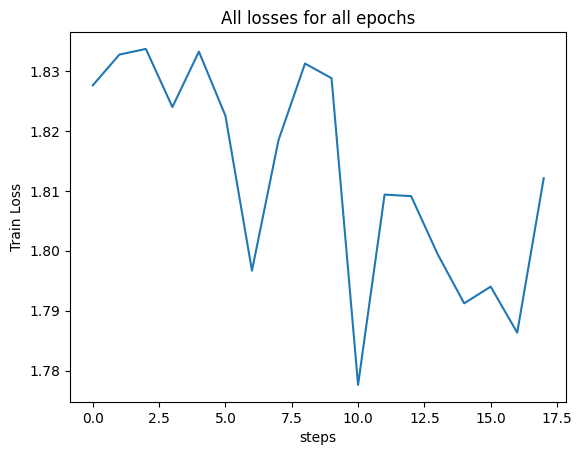

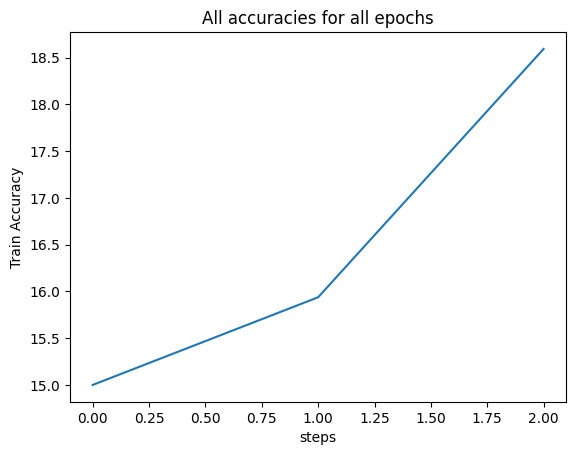

710
Step: 5 From 23
Tes loss: 1.7938047647476196 Preds: tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0], device='cuda:0') Labels: tensor([2, 4, 4, 1, 2, 5, 4, 2, 0, 4, 0, 3, 4, 0, 2, 0, 1, 5, 5, 4, 2, 4, 0, 1,
        1, 4, 2, 4, 4, 4, 4, 5, 0, 1, 0, 2, 5, 2, 2, 4, 0, 4, 1, 5, 5, 1, 1, 2,
        3, 3, 5, 3, 3, 4, 1, 3, 4, 2, 4, 1, 5, 0, 3, 1, 0, 1, 0, 3, 4, 5, 5, 1,
        2, 4, 3, 2, 3, 2, 5, 1, 4, 3, 2, 2, 4, 3, 5, 1, 0, 2, 3, 5, 2, 5, 3, 0,
        0, 1, 3, 0, 2, 0, 1, 2, 4, 5, 1, 0, 2, 3, 4, 4, 4, 4, 0, 0, 4, 1, 3, 3,
        1, 5, 4, 5, 1, 5, 5, 2], device='cuda:0')
Test Accuracy For 20 Steps:  15.1562

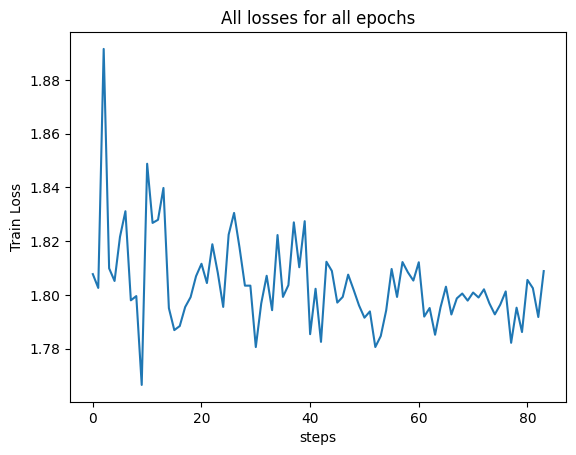

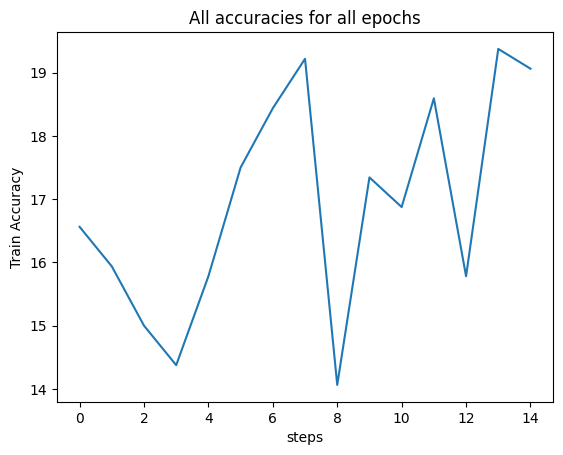

3551
Step: 5 From 23
Tes loss: 1.7902425527572632 Preds: tensor([0, 4, 4, 0, 4, 0, 4, 4, 0, 0, 4, 4, 4, 4, 0, 0, 0, 0, 0, 4, 4, 0, 0, 4,
        0, 0, 4, 0, 0, 0, 0, 4, 0, 0, 0, 4, 4, 0, 4, 4, 0, 4, 4, 0, 4, 4, 0, 4,
        0, 0, 0, 0, 4, 0, 0, 0, 0, 4, 4, 4, 4, 4, 0, 4, 0, 0, 4, 0, 0, 4, 0, 0,
        4, 4, 4, 4, 4, 4, 4, 0, 4, 0, 4, 4, 4, 4, 4, 0, 0, 0, 4, 0, 0, 0, 4, 0,
        0, 0, 0, 4, 4, 4, 4, 0, 4, 0, 4, 4, 0, 4, 0, 0, 4, 4, 0, 0, 0, 4, 0, 0,
        4, 0, 0, 4, 0, 0, 0, 0], device='cuda:0') Labels: tensor([2, 4, 4, 2, 3, 0, 4, 0, 3, 3, 4, 4, 4, 4, 0, 1, 2, 0, 0, 5, 4, 5, 1, 0,
        5, 1, 1, 0, 0, 1, 1, 4, 3, 2, 3, 4, 4, 5, 3, 4, 2, 5, 4, 5, 3, 4, 3, 2,
        0, 1, 5, 5, 3, 2, 1, 2, 1, 4, 4, 2, 4, 4, 2, 0, 1, 2, 5, 3, 1, 4, 3, 0,
        4, 0, 3, 5, 1, 4, 5, 2, 1, 3, 5, 0, 0, 0, 1, 3, 1, 3, 4, 3, 1, 3, 5, 3,
        2, 0, 5, 2, 1, 4, 1, 2, 3, 2, 2, 2, 0, 3, 5, 2, 3, 0, 3, 5, 3, 1, 5, 1,
        3, 0, 3, 0, 1, 1, 0, 5], device='cuda:0')
Test Accuracy For 20 Steps:  25.781

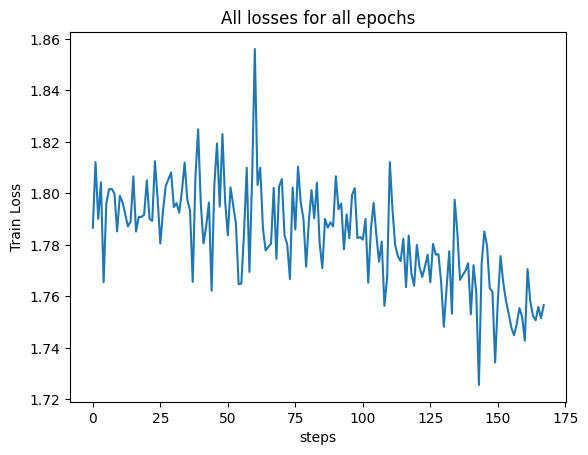

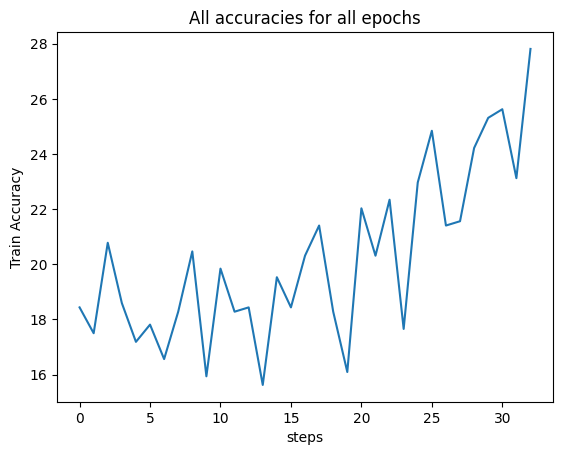

7102
Step: 5 From 23
Tes loss: 1.7464228868484497 Preds: tensor([0, 4, 1, 1, 1, 0, 4, 1, 0, 2, 4, 1, 4, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1,
        4, 1, 4, 0, 2, 0, 0, 0, 0, 4, 1, 4, 1, 0, 0, 1, 4, 1, 4, 1, 0, 1, 1, 1,
        0, 0, 1, 4, 1, 4, 1, 0, 4, 4, 0, 4, 1, 4, 1, 0, 1, 0, 4, 2, 4, 1, 2, 0,
        4, 0, 0, 1, 4, 0, 4, 2, 0, 1, 0, 0, 2, 0, 1, 0, 4, 0, 1, 1, 4, 4, 1, 1,
        4, 1, 4, 1, 4, 2, 1, 1, 0, 4, 1, 0, 1, 4, 1, 1, 1, 0, 0, 1, 1, 0, 1, 4,
        0, 1, 0, 0, 4, 1, 5, 2], device='cuda:0') Labels: tensor([0, 4, 5, 3, 0, 5, 0, 2, 0, 3, 4, 3, 5, 1, 5, 3, 0, 5, 0, 1, 5, 2, 2, 5,
        4, 3, 4, 2, 3, 5, 0, 2, 4, 5, 5, 4, 0, 5, 2, 3, 3, 2, 4, 5, 5, 2, 5, 2,
        1, 1, 2, 1, 5, 1, 2, 5, 1, 4, 0, 1, 1, 0, 1, 1, 3, 0, 4, 2, 0, 5, 5, 1,
        4, 3, 1, 3, 4, 1, 3, 3, 3, 5, 0, 3, 3, 0, 3, 0, 3, 1, 1, 3, 4, 4, 3, 2,
        4, 5, 4, 2, 4, 2, 3, 2, 5, 0, 2, 4, 0, 4, 0, 1, 5, 3, 3, 5, 1, 1, 2, 0,
        1, 2, 5, 0, 3, 3, 2, 2], device='cuda:0')
Test Accuracy For 20 Steps:  28.593

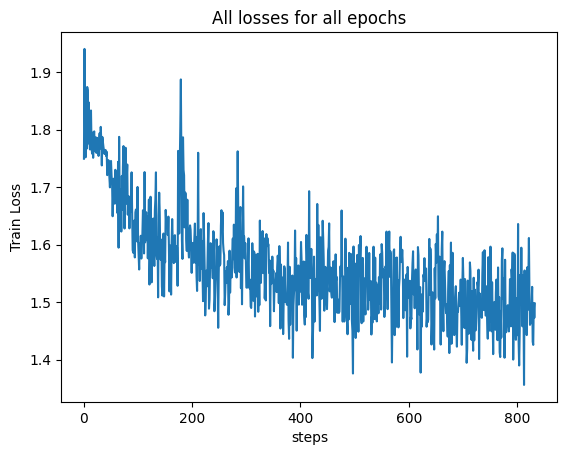

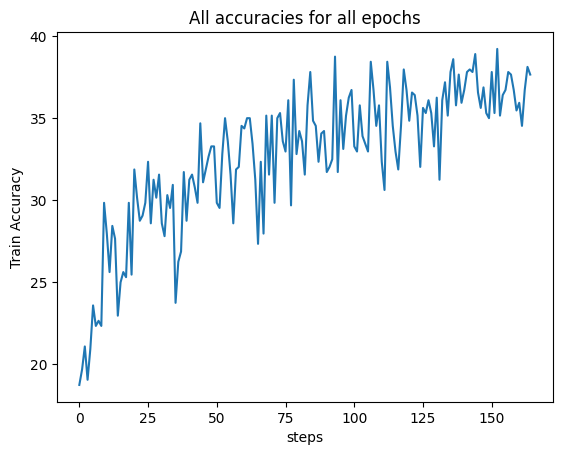

35513
Step: 5 From 23
Tes loss: 1.521824598312378 Preds: tensor([0, 2, 0, 1, 1, 0, 4, 4, 0, 4, 3, 0, 0, 1, 4, 1, 4, 0, 3, 5, 5, 4, 1, 2,
        0, 0, 1, 1, 5, 2, 1, 1, 1, 4, 0, 2, 2, 4, 4, 1, 2, 0, 2, 2, 2, 4, 2, 4,
        3, 1, 2, 1, 4, 0, 4, 1, 0, 4, 0, 1, 3, 2, 2, 0, 2, 3, 2, 2, 4, 2, 5, 4,
        2, 3, 0, 3, 1, 2, 4, 4, 4, 0, 3, 1, 0, 4, 2, 1, 3, 0, 5, 5, 4, 3, 0, 3,
        2, 5, 0, 2, 1, 0, 2, 2, 4, 2, 4, 1, 0, 2, 4, 0, 5, 1, 4, 5, 5, 0, 0, 2,
        2, 5, 4, 4, 1, 5, 5, 4], device='cuda:0') Labels: tensor([2, 3, 0, 2, 3, 0, 4, 4, 5, 4, 0, 3, 0, 2, 4, 1, 1, 0, 5, 5, 1, 0, 2, 3,
        1, 3, 2, 1, 5, 5, 3, 0, 1, 0, 1, 3, 0, 4, 0, 1, 1, 5, 5, 3, 5, 4, 1, 4,
        1, 5, 1, 3, 0, 1, 0, 1, 0, 0, 3, 0, 1, 2, 0, 2, 2, 5, 0, 3, 4, 3, 5, 4,
        0, 5, 0, 0, 0, 2, 4, 4, 4, 1, 0, 1, 2, 4, 1, 3, 0, 2, 3, 3, 0, 2, 5, 1,
        3, 1, 1, 3, 3, 1, 2, 0, 4, 5, 4, 0, 1, 3, 4, 1, 2, 2, 4, 2, 2, 1, 5, 2,
        5, 0, 0, 4, 2, 2, 0, 1], device='cuda:0')
Test Accuracy For 20 Steps:  32.812

In [14]:
########## Training the model of all the percentages
bert_model=model_with_adapters
bert_model=to_device(bert_model,device)




average_accs_for_all_percentages=[]

test_dataset = BERT_Dataset(text = all_texts_test,
                                labels = all_labels_test,
                                label_masks=torch.ones(len(all_labels_test)).to(device),
                                max_len = max_len)

test_loader = DataLoader(test_dataset, batch_size = batch_size, shuffle = True)
test_loader = DeviceDataLoader(test_loader, device)

loss_fn = torch.nn.CrossEntropyLoss()


for percentage_index in range(len(percentage)):


    print("##############################\n\n\n")

    print("This model considers",100*percentage[percentage_index],"% of the data for supervised learning, so all other data are redundant in part 1")
    # We Define a mask for implementing semi-supervised, we won't use this mask in part 1.

    all_labels_masks=torch.ones(len(all_labels),dtype=bool).to(device)
    for i in range(int(percentage[percentage_index]*len(all_texts_shuffled)),len(all_texts_shuffled)):
      all_labels_masks[i]=False





    train_dataset_with_label = BERT_Dataset(text = all_texts_shuffled[:int(percentage[percentage_index]*len(all_texts_shuffled))],
                                labels = all_labels_shuffled[:int(percentage[percentage_index]*len(all_texts_shuffled))],
                                label_masks=all_labels_masks[:int(percentage[percentage_index]*len(all_texts_shuffled))],
                                max_len = max_len)


    # used_train_dataset_with_label,non_used_train_dataset_with_label=torch.utils.data.random_split(train_dataset_with_label,[int(0.1*len(train_dataset_with_label)), len(train_dataset_with_label)-int(0.1*len(train_dataset_with_label))])


    # train_loader_with_label = DataLoader(used_train_dataset_with_label, batch_size = batch_size, shuffle = False)


    train_loader_with_label = DataLoader(train_dataset_with_label, batch_size = batch_size, shuffle = True)




    train_loader_with_label = DeviceDataLoader(train_loader_with_label, device)






    print("We have ",len(train_dataset_with_label),"Data for train")

    #print("We have ",len(used_train_dataset_with_label),"Data for train")


    print("We have ",len(test_dataset),"Data for test")







    total_steps = len(train_loader_with_label) * epochs






    # We have 6 classes for classification, so we have:

    # num_class = 6

    # bert_model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=num_class)

    # bert_model = to_device(bert_model, device)

    optimizer = torch.optim.AdamW(bert_model.parameters(), lr=learning_rate)

    scheduler = get_linear_schedule_with_warmup(
      optimizer,
      num_warmup_steps=0,
      num_training_steps=total_steps
    )

    total_loss_for_all_epochs=[]
    total_acc_for_all_epochs=[]

    print("\n\n\n\n\nTraining has been started!!")
    print("################################ \n\n\n\n\n\n")


    tic=time.time()
    for epoch in range(epochs):
        bert_model.train()
        total_loss=[]
        total_acc=[]
        total_samples= 0
        total_correct= 0
        i=0
        for batch in train_loader_with_label:
            i=i+1
            input_ids, attention_mask, token_type_ids, label,_ = batch

            optimizer.zero_grad()


            outputs = bert_model(input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids, labels=label)


            #loss=loss_fn(outputs.logits,label)
            loss = outputs.loss


            total_loss.append(loss.item())
            total_loss_for_all_epochs.append(loss.item())
            loss.backward()
            optimizer.step()
            scheduler.step()
            print("Step:",i,"  From",len(train_dataset_with_label)//batch_size, "  Loss:",loss.item())
            _, preds = torch.max(outputs[1], dim = 1)
            total_samples += label.size(0)
            total_correct += (preds == label).sum().item()


            if i%5 == 0:
              acc_train=100*total_correct/total_samples

              print("Train Accuracy For 20 Steps: ",acc_train,"%")
              total_correct=0
              total_samples=0
              total_acc.append(acc_train)
              total_acc_for_all_epochs.append(acc_train)

        print(f"Epoch {epoch + 1}/{epochs}")
        print("Average Train Loss:", torch.mean(torch.tensor(total_loss)),"Average Train Accuracy:", torch.mean(torch.tensor(total_acc)))


    toc=time.time()

    print("Elapsed time is",round(toc-tic,5),"seconds")

    plt.plot(total_loss_for_all_epochs)
    plt.title("All losses for all epochs")
    plt.ylabel("Train Loss")
    plt.xlabel("steps")

    plt.show()

    plt.plot(total_acc_for_all_epochs)
    plt.title("All accuracies for all epochs")
    plt.ylabel("Train Accuracy")
    plt.xlabel("steps")

    plt.show()

    print(len(train_dataset_with_label))


    bert_model.eval()
    total_loss = 0.0
    i = 0
    total_loss=[]
    total_acc=[]
    total_samples= 0
    total_correct= 0
    for batch in test_loader:
        i += 1
        input_ids, attention_mask, token_type_ids, label, label_mask = batch

        outputs = bert_model(input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids, labels=label)
        loss = outputs.loss
        total_loss.append(loss.item())


        _, preds = torch.max(outputs[1], dim = 1)
        total_samples += label.size(0)
        total_correct += (preds == label).sum().item()

        if i%5 == 0:
          acc=100*total_correct/total_samples
          total_acc.append(acc)
          print("Step:",i,"From",len(test_dataset)//batch_size)
          print('Tes loss:',loss.item(),'Preds:',preds,"Labels:",label)
          print("Test Accuracy For 20 Steps: ",acc,"%")
          total_correct=0
          total_samples=0


    average_loss =torch.mean(torch.tensor(total_loss))
    average_acc =torch.mean(torch.tensor(total_acc))
    print("Average Test Loss:",average_loss,"\nAverage Test Accuracy:",average_acc)

    average_accs_for_all_percentages.append(average_acc)



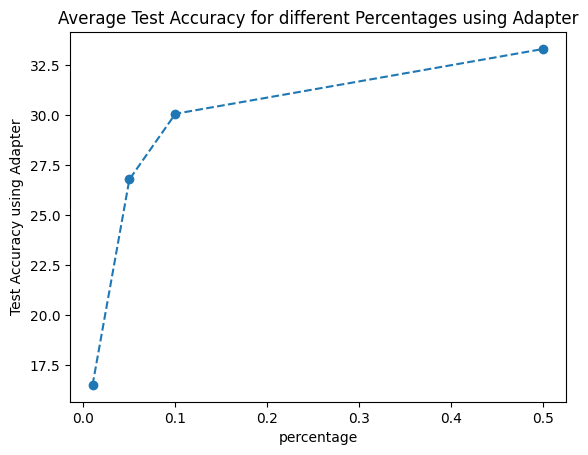

Data saved to data.xlsx


In [15]:
import pandas as pd


plt.plot(percentage,average_accs_for_all_percentages, marker='o', linestyle='--')
plt.title("Average Test Accuracy for different Percentages using Adapter")
plt.ylabel("Test Accuracy using Adapter")
plt.xlabel("percentage")


plt.show()

df = pd.DataFrame({'percent': percentage, 'acc': average_accs_for_all_percentages})

# Save the DataFrame to an Excel file
df.to_excel('data.xlsx', index=False)

print("Data saved to data.xlsx")

# Part2 - Adapter (Bonus) - Method 2

In [16]:
!pip -q install  adapter-transformers
from transformers.adapters import AdapterType, AdapterConfig

print("Done!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.4/6.4 MB 18.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.1/200.1 kB 15.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 51.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
transformers 4.35.2 requires huggingface-hub<1.0,>=0.16.4, but you have huggingface-hub 0.13.4 which is incompatible.
transformers 4.35.2 requires tokenizers<0.19,>=0.14, but you have tokenizers 0.13.3 which is incompatible.
Done!


/usr/local/lib/python3.10/dist-packages/transformers/adapters/__init__.py:27: FutureWarning: The `adapter-transformers` package is deprecated and replaced by the `adapters` package. See https://docs.adapterhub.ml/transitioning.html.
  warnings.warn(


In [17]:
!pip install transformers==4.3.0


from transformers import AutoModelWithHeads,PfeifferConfig

model_name = "bert-base-uncased"
model = AutoModelWithHeads.from_pretrained(model_name)

# Create a new adapter configuration
adapter_config = PfeifferConfig(
    hidden_size=64, 
    non_linearity="swish",
    reduction_factor=4,
    residual_before_ln=True,
)

# Add an adapter module to the model based on the configuration
adapter_name = "text_classification_adapter"


model.add_adapter(adapter_name, config=adapter_config)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 7.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.5/897.5 kB 17.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.7/212.7 kB 17.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  error: subprocess-exited-with-error
  
  × Building wheel for tokenizers (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for tokenizers
Failed to build tokenizers
ERROR: Could not build wheels for tokenizers, which is required to install pyproject.toml-based projects


ImportError: cannot import name 'AutoModelWithHeads' from 'transformers' (/usr/local/lib/python3.10/dist-packages/transformers/__init__.py)

In [ ]:
# # Install the required libraries and peft in Colab
# !pip install --upgrade huggingface-hub==0.17.0
# !pip install --upgrade tokenizers==0.14

# # Install peft
# !pip install peft

# bert_model = BertModel.from_pretrained("bert-base-uncased")

# m=512
# adapter_name = "my_adapter"
# adapter_config = {"adapter_dim": m}
# bert_model.add_adapter(adapter_name, m)

In [ ]:
########## Training the model of all the percentages
bert_model=model





average_accs_for_all_percentages=[]

test_dataset = BERT_Dataset(text = all_texts_test,
                                labels = all_labels_test,
                                label_masks=torch.ones(len(all_labels_test)).to(device),
                                max_len = max_len)

test_loader = DataLoader(test_dataset, batch_size = batch_size, shuffle = True)
test_loader = DeviceDataLoader(test_loader, device)

loss_fn = torch.nn.CrossEntropyLoss()


for percentage_index in range(3,len(percentage)):


    print("##############################\n\n\n")

    print("This model considers",100*percentage[percentage_index],"% of the data for supervised learning, so all other data are redundant in part 1")
    # We Define a mask for implementing semi-supervised, we won't use this mask in part 1.

    all_labels_masks=torch.ones(len(all_labels),dtype=bool).to(device)
    for i in range(int(percentage[percentage_index]*len(all_texts_shuffled)),len(all_texts_shuffled)):
      all_labels_masks[i]=False





    train_dataset_with_label = BERT_Dataset(text = all_texts_shuffled[:int(percentage[percentage_index]*len(all_texts_shuffled))],
                                labels = all_labels_shuffled[:int(percentage[percentage_index]*len(all_texts_shuffled))],
                                label_masks=all_labels_masks[:int(percentage[percentage_index]*len(all_texts_shuffled))],
                                max_len = max_len)


    # used_train_dataset_with_label,non_used_train_dataset_with_label=torch.utils.data.random_split(train_dataset_with_label,[int(0.1*len(train_dataset_with_label)), len(train_dataset_with_label)-int(0.1*len(train_dataset_with_label))])


    # train_loader_with_label = DataLoader(used_train_dataset_with_label, batch_size = batch_size, shuffle = False)


    train_loader_with_label = DataLoader(train_dataset_with_label, batch_size = batch_size, shuffle = True)




    train_loader_with_label = DeviceDataLoader(train_loader_with_label, device)






    print("We have ",len(train_dataset_with_label),"Data for train")

    #print("We have ",len(used_train_dataset_with_label),"Data for train")


    print("We have ",len(test_dataset),"Data for test")







    total_steps = len(train_loader_with_label) * epochs






    # We have 6 classes for classification, so we have:

    # num_class = 6

    # bert_model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=num_class)

    # bert_model = to_device(bert_model, device)

    optimizer = torch.optim.AdamW(bert_model.parameters(), lr=learning_rate)

    scheduler = get_linear_schedule_with_warmup(
      optimizer,
      num_warmup_steps=0,
      num_training_steps=total_steps
    )

    total_loss_for_all_epochs=[]
    total_acc_for_all_epochs=[]

    print("\n\n\n\n\nTraining has been started!!")
    print("################################ \n\n\n\n\n\n")


    tic=time.time()
    for epoch in range(epochs):
        bert_model.train()
        total_loss=[]
        total_acc=[]
        total_samples= 0
        total_correct= 0
        i=0
        for batch in train_loader_with_label:
            i=i+1
            input_ids, attention_mask, token_type_ids, label,_ = batch

            optimizer.zero_grad()


            outputs = bert_model(input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids, labels=label)


            #loss=loss_fn(outputs.logits,label)
            loss = outputs.loss


            total_loss.append(loss.item())
            total_loss_for_all_epochs.append(loss.item())
            loss.backward()
            optimizer.step()
            scheduler.step()
            print("Step:",i,"  From",len(train_dataset_with_label)//batch_size, "  Loss:",loss.item())
            _, preds = torch.max(outputs[1], dim = 1)
            total_samples += label.size(0)
            total_correct += (preds == label).sum().item()


            if i%5 == 0:
              acc_train=100*total_correct/total_samples

              print("Train Accuracy For 20 Steps: ",acc_train,"%")
              total_correct=0
              total_samples=0
              total_acc.append(acc_train)
              total_acc_for_all_epochs.append(acc_train)

        print(f"Epoch {epoch + 1}/{epochs}")
        print("Average Train Loss:", torch.mean(torch.tensor(total_loss)),"Average Train Accuracy:", torch.mean(torch.tensor(total_acc)))


    toc=time.time()

    print("Elapsed time is",round(toc-tic,5),"seconds")

    plt.plot(total_loss_for_all_epochs)
    plt.title("All losses for all epochs")
    plt.ylabel("Train Loss")
    plt.xlabel("steps")

    plt.show()

    plt.plot(total_acc_for_all_epochs)
    plt.title("All accuracies for all epochs")
    plt.ylabel("Train Accuracy")
    plt.xlabel("steps")

    plt.show()

    print(len(train_dataset_with_label))


    bert_model.eval()
    total_loss = 0.0
    i = 0
    total_loss=[]
    total_acc=[]
    total_samples= 0
    total_correct= 0
    for batch in test_loader:
        i += 1
        input_ids, attention_mask, token_type_ids, label, label_mask = batch

        outputs = bert_model(input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids, labels=label)
        loss = outputs.loss
        total_loss.append(loss.item())


        _, preds = torch.max(outputs[1], dim = 1)
        total_samples += label.size(0)
        total_correct += (preds == label).sum().item()

        if i%5 == 0:
          acc=100*total_correct/total_samples
          total_acc.append(acc)
          print("Step:",i,"From",len(test_dataset)//batch_size)
          print('Tes loss:',loss.item(),'Preds:',preds,"Labels:",label)
          print("Test Accuracy For 20 Steps: ",acc,"%")
          total_correct=0
          total_samples=0


    average_loss =torch.mean(torch.tensor(total_loss))
    average_acc =torch.mean(torch.tensor(total_acc))
    print("Average Test Loss:",average_loss,"\nAverage Test Accuracy:",average_acc)

    average_accs_for_all_percentages.append(average_acc)



In [ ]:
import pandas as pd


plt.plot(percentage,average_accs_for_all_percentages, marker='o', linestyle='--')
plt.title("Average Test Accuracy for different Percentages using Adapter")
plt.ylabel("Test Accuracy using Adapter")
plt.xlabel("percentage")


plt.show()

df = pd.DataFrame({'percent': percentage, 'acc': average_accs_for_all_percentages})

# Save the DataFrame to an Excel file
df.to_excel('data.xlsx', index=False)

print("Data saved to data.xlsx")